In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [4]:
# write our state schema
class AgentState(TypedDict):
    name: str
    age: int


In [6]:
# Our node--> steps that will update the state above
def get_name(state: AgentState)-> AgentState:
    """Converts name to uppercase"""
    # the input turn it to uppercase
    state['name']=state['name'].upper()

    # return the new state
    return state

def add_age(state: AgentState)-> AgentState:
    """Updates the Age"""
    state['age']=25

    return state


In [9]:
# create our graph
graph=StateGraph(AgentState)

# add the nodes
graph.add_node("uppercase", get_name)
graph.add_node("age_update", add_age)

# add the edges---> connecting the nodes
graph.set_entry_point("uppercase")
graph.add_edge("uppercase", "age_update")
graph.set_finish_point("age_update")

# compile the graph
app=graph.compile()


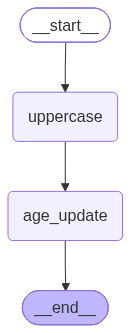

In [10]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
app.invoke({"name":"allan"})

{'name': 'ALLAN', 'age': 25}